# Module 2 — Tokenization and Embedding


## Setup

*these will be present in the beginning of all the notebooks to make sure the environment is setup correctly in Colab*

### Setup Notebook Environment

### Installing Python Libraries

**In Colab**, this might ask you to restart your session, do so and if you face issues that Gemini can't help you with ask the TA.

In [ ]:
# ============================================================
# COLAB INSTALL CELL (NO IMPORTS HERE)
# ============================================================

import subprocess

def run(cmd):
    print(f"\n>>> {cmd}\n")
    subprocess.run(cmd, shell=True, check=True)

print("\n================================================")
print("STEP 1: FIX NUMPY (CRITICAL)")
print("================================================\n")

run("pip uninstall -y numpy || true")
run("pip install --no-cache-dir numpy==1.26.4")

print("\n================================================")
print("STEP 2: CORE PACKAGES")
print("================================================\n")

run(
    "pip install -U --no-cache-dir "
    "unsloth ollama "
    "transformers==5.5.0 "
    "chromadb==0.5.5 "
    "posthog==2.5.0"
)

print("\n================================================")
print("STEP 3: SYSTEM DEPENDENCIES")
print("================================================\n")

run("apt-get update -y && apt-get install -y zstd")

print("\n================================================")
print("STEP 4: OLLAMA INSTALL")
print("================================================\n")

run("curl -fsSL https://ollama.com/install.sh | sh")


# SAFE STOP MESSAGE (DO NOT AUTO CRASH)
from IPython.display import display, HTML

display(HTML("""
<div style="padding:16px;border-radius:10px;border:1px solid #ddd;background:#f8f9fa;font-family:Arial">
<h2 style="color:green;">✔ Install Complete</h2>

<p><b>Now you MUST restart runtime:</b></p>
<p>Runtime → Restart session</p>

<p style="color:gray;font-size:13px;">
This is required to fix NumPy / Torch binary compatibility.
</p>
</div>
"""))

### Restart Session

👉 Runtime → Restart session

Get Ollama (this is what we are using to interact with the model and manage it)

In [ ]:
# ============================================================
# COLAB RUNTIME CELL (IMPORTS ONLY)
# ============================================================

import unsloth
import torch
import transformers

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA Available:", torch.cuda.is_available())

# Ollama is SYSTEM binary, not Python package
import subprocess
print("Ollama installed:", subprocess.run(["which", "ollama"], capture_output=True).returncode == 0)

# ------------------------------------------------------------
# Detect Colab
# ------------------------------------------------------------

try:
    import google.colab
    IN_COLAB = True
    print("Running on Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running locally")


# ------------------------------------------------------------
# HTML helper (ONLY used in Colab)
# ------------------------------------------------------------

def show_status(title, lines, color="#4CAF50"):
    if not IN_COLAB:
        return

    from IPython.display import display, HTML

    html = f"""
    <div style="
        padding:16px;
        border-radius:10px;
        border:1px solid #ddd;
        background:#f9f9f9;
        font-family:Arial;
        margin-top:10px;
    ">
        <h2 style="color:{color}; margin:0;">{title}</h2>
        <ul>
            {''.join(f'<li>{l}</li>' for l in lines)}
        </ul>
    </div>
    """
    display(HTML(html))


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def run(cmd):
    print(f"\n>>> {cmd}\n")
    subprocess.run(cmd, shell=True, check=True)


def is_binary_installed(name: str) -> bool:
    return subprocess.run(
        ["which", name],
        capture_output=True
    ).returncode == 0


# ------------------------------------------------------------
# FIXED: correct course name
# ------------------------------------------------------------

def find_course_dir_gdrive() -> str:

    matches = []

    for m in glob.glob('/content/drive/**/pyproject.toml', recursive=True):

        try:
            with open(m, "r") as f:
                content = f.read()

                if 'applied-language-models-course' in content:
                    matches.append(os.path.dirname(m))

        except Exception:
            pass

    if not matches:
        return input("Enter path to student_scaffolding folder: ")

    return matches[0]


# ------------------------------------------------------------
# Colab setup
# ------------------------------------------------------------

status_lines = []

if IN_COLAB:

    print("\nInstalling system dependencies...\n")
    run("apt-get update -y && apt-get install -y zstd")
    status_lines.append("zstd installed")

    # --------------------------------------------------------
    # Install Ollama
    # --------------------------------------------------------

    if not is_binary_installed("ollama"):
        print("\nInstalling Ollama...\n")
        run("curl -fsSL https://ollama.com/install.sh | sh")
        status_lines.append("Ollama installed")
    else:
        status_lines.append("Ollama already present")


# ------------------------------------------------------------
# Python imports
# ------------------------------------------------------------

import torch
import transformers

try:
    import unsloth
    status_lines.append("Unsloth imported successfully")
except Exception as e:
    status_lines.append(f"Unsloth import failed: {e}")


status_lines.extend([
    f"Torch: {torch.__version__}",
    f"Transformers: {transformers.__version__}",
    f"CUDA Available: {torch.cuda.is_available()}"
])


# ------------------------------------------------------------
# SHOW FINAL STATUS UI
# ------------------------------------------------------------

show_status(
    "✔ Environment Setup Complete",
    status_lines,
    color="#2E7D32"
)


if IN_COLAB and is_binary_installed("ollama"):
    print("\nOllama is installed. Start it with:")
    print("  !ollama serve")
    print("Then use HTTP API on port 11434")

print("\nEnvironment ready.")

Getting the data and making sure we are in the right root directory.

There are two recommended ways,
- Upload to drive from your local using "setup assistant"
- Use github with PAT token

While we have tried to accommodate different styles of working there might still be exceptions and ways of doing this that we might have skipped to test.

**Getting the PAT from Github**

[Documentation](https://dev.to/warnerbell/how-to-generate-a-github-personal-access-token-pat-1bg5)

Options:
  - Choose Classic Token
  - Give access to repo

In [ ]:
if IN_COLAB:
    import os
    import subprocess
    import zipfile
    import getpass

    # ----------------------------
    # CONFIG
    # ----------------------------
    REPO_URL = "https://github.com/watspeed/language-models.git"
    TARGET_DIR = "/content/repo"

    # Optional: set to None or a branch name
    REPO_BRANCH = None  # or None for main

    # ----------------------------
    # MENU
    # ----------------------------
    print("""
    📦 Project Loader Options:

    1 - Auto (Drive → Git → ZIP)
    2 - Git only
    3 - ZIP upload
    """)

    choice = input("Enter choice (1, 2, 3): ").strip()

    # ----------------------------
    # DRIVE (optional)
    # ----------------------------
    def try_drive():
        try:
            from google.colab import drive
            drive.mount('/content/drive')

            default_path = "/content/drive/MyDrive/watspeed_llm_course"
            if os.path.exists(default_path):
                print(f"📁 Default path found: {default_path}")
                return default_path

            print("🔄 Searching Google Drive...")

            path = find_course_dir_gdrive()  # optional external helper

            if path:
                print(f"📁 Drive found: {path}")
                return path

        except Exception as e:
            print("⚠️ Drive failed:", e)

        return None


    # ----------------------------
    # GIT (MAIN + BRANCH SUPPORT)
    # ----------------------------
    def try_git(repo_url, branch=None):
        try:
            if os.path.exists(TARGET_DIR):
                print("📁 Repo already exists, reusing...")
                return TARGET_DIR

            # default branch = main
            branch = branch or "main"

            print(f"🔄 Cloning repo (branch: {branch})...")

            def run_clone(url):
                return subprocess.run(
                    ["git", "clone", "--branch", branch, "--single-branch", url, TARGET_DIR],
                    text=True,
                    capture_output=True
                )

            # 1) try public clone
            result = run_clone(repo_url)

            if result.returncode == 0:
                return TARGET_DIR

            print("⚠️ Public clone failed. Trying PAT...")

            # 2) PAT fallback
            token = getpass.getpass("🔐 Enter GitHub PAT: ")

            auth_url = repo_url.replace(
                "https://", f"https://{token}:x-oauth-basic@"
            )

            result = run_clone(auth_url)

            if result.returncode == 0:
                return TARGET_DIR

            print("❌ Git clone failed")
            print(result.stderr)
            return None

        except Exception as e:
            print("⚠️ Git error:", e)
            return None


    # ----------------------------
    # ZIP IMPORT
    # ----------------------------
    def try_zip():
        print("📦 Upload ZIP...")
        from google.colab import files

        uploaded = files.upload()
        if not uploaded:
            print("⚠️ No file uploaded")
            return None

        zip_file = list(uploaded.keys())[0]

        try:
            with zipfile.ZipFile(zip_file, 'r') as z:
                z.extractall("/content")
        except zipfile.BadZipFile:
            print("❌ Invalid ZIP file")
            return None

        folder = zip_file.replace(".zip", "")
        path = os.path.join("/content", folder)

        print(f"📁 Extracted: {path}")
        return path


    # ----------------------------
    # MAIN LOGIC
    # ----------------------------
    project_path = None

    if choice == "2":
        project_path = try_git(REPO_URL, REPO_BRANCH)

    elif choice == "3":
        project_path = try_zip()

    else:
        # AUTO MODE
        project_path = try_drive()

        if not project_path:
            project_path = try_git(REPO_URL, REPO_BRANCH)

        if not project_path:
            project_path = try_zip()


    # ----------------------------
    # FINAL STEP
    # ----------------------------
    if project_path and os.path.exists(project_path):
        try:
            os.chdir(project_path)
            print("✅ Active directory:", os.getcwd())
            print("📂 Contents:", os.listdir())
        except Exception as e:
            print("❌ Failed to switch directory:", e)
    else:
        print("❌ No project loaded")

else:
    def in_root_folder() -> bool:
        return os.path.isdir("notebooks") and os.path.isdir("data")

    if not in_root_folder():
        import os
        os.chdir("..")

In [3]:
from IPython.display import display, Markdown

### Start Ollama and Load the Model

In [ ]:
if IN_COLAB:
    import subprocess, time
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    time.sleep(3)  # give it a moment to start

!ollama pull gemma2:2b
!ollama pull embeddinggemma

In [ ]:
import ollama

ollama.generate(
    model="gemma2:2b",
    prompt="hi, who is out there?"
).response

---

### What is a Token?

In Module 1 we saw that an LLM predicts the *next token*. But what exactly is a token?

A token is not the same as a word. It's a chunk of text that the model's vocabulary knows about. Each model has a fixed vocabulary; for example, [Qwen3-8B](https://huggingface.co/Qwen/Qwen3-8B/blob/main/config.json) has `vocab_size: 151936` and Gemma has `Vocab Size: 256128` [(paper)](https://arxiv.org/html/2408.00118v3)

Some of these tokens are full words: `recipe`, `chicken`, `bake` and some are split into partial words to optimize what can be represented in the vocabulary for example, `sourdough` might become `sour` + `dough`.

Some are punctuation, spaces, or special markers depending on the model we are choosing and their corresponding embedding model.

This matters for our use case: if our domain uses unusual words (medical terms, proprietary names, niche cuisine vocabulary), those words might not exist as single tokens and will be split into smaller pieces — which changes how the model "sees" and "understands" them.

---
### What is an Embedding?

Once text is broken into tokens, each token gets converted into a list of numbers called a **vector**, or **embedding** — this is the representation the LLM actually operates on; together, these vectors form an embedding space.

We can imagine the embedding space to be like coordinates on a map. Words with similar meanings end up close together in this high-dimensional space:
- `bake`, `roast`, `grill` — close to each other
- `sourdough`, `fermentation` — close to each other
- `sourdough`, `combustion engine` — far apart

The LLM does all its reasoning in this embedding space. It never actually sees our text — only these vectors.

**The Pipeline so far**
```
Our text → Tokenizer → Token IDs → Embedding layer → Vectors → Transformer layers → Next token prediction
```

Tokenization matters, because if a word gets split into pieces the model barely recognizes, its embedding will be weak, and the model's reasoning about it and how it relates to a concept suffers. The model's outputs on those terms will be weaker or less precise.


In [ ]:
import ollama
from IPython.display import display, Markdown


result = ollama.generate(
    model="gemma2:2b",
    prompt="Should I operate on Histonamy using the clongs from planet of the apes"
)


display(Markdown("**Gemma says:**" + result.response))

**Exercise 2.1:**

Write a prompt that produces varied or unexpected outputs.

In [ ]:
input_prompt = input()
result = ollama.generate(
    model="gemma2:2b",
    prompt=input_prompt
)


display(Markdown("**Gemma says:**" + result.response))

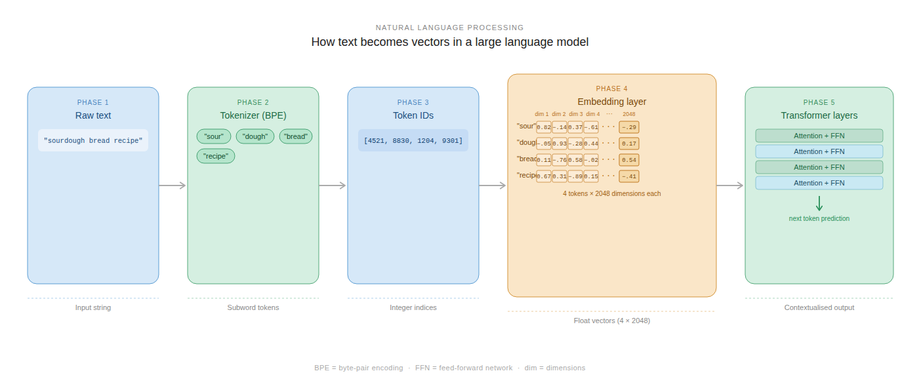
> **[Diagram Caption]** Five-phase pipeline titled "How text becomes vectors in a large language model." Phase 1 (blue): Raw text — the string "sourdough bread recipe." Phase 2 (green): Tokenizer (BPE) — splits into subword tokens "sour", "dough", "bread", "recipe." Phase 3 (green): Token IDs — integer list [4521, 8830, 1204, 9301]. Phase 4 (orange): Embedding layer — a 4 × 2048 float matrix, with one row of sample values visible per token. Phase 5 (green): Transformer layers — four stacked Attention + FFN blocks with a "next token prediction" arrow at the bottom. Footer labels read: Input string → Subword tokens → Integer indices → Float vectors (4 × 2048) → Contextualised output.


---

### Tokenizing Text

The interactive tool above shows how Gemma's tokenizer splits text into tokens — try typing
words from our domain. Below we replicate the same view in code using the `all-MiniLM-L6-v2`
tokenizer. The vocabulary differs (Gemma uses SentencePiece BPE; this model uses WordPiece),
but both operate on subword units, though the specific merge strategies differ (BPE vs WordPiece).

Each colored block below is one token.

In [8]:
%%HTML
<div style="background-color: white; padding: 15px; border-radius: 8px; width: 100%;">
    <iframe src="https://tiktokenizer.vercel.app/?model=google%2Fgemma-7b"
            width="100%"
            height="600px"
            style="border: none; background-color: white; color-scheme: light;">
    </iframe>
</div>

In [9]:
from transformers import AutoTokenizer
from IPython.display import display, HTML

COLORS = ["#ffd6a5", "#fdffb6", "#caffbf", "#9bf6ff", "#a0c4ff", "#bdb2ff", "#ffc6ff"]

def render(title, tokens, ids):
    spans = []

    for i, (t, tid) in enumerate(zip(tokens, ids)):
        color = COLORS[i % len(COLORS)]

        if t.startswith("##"):
            disp, sep = t[2:], ""
        elif t.startswith("▁"):
            disp, sep = t[1:], " "
        else:
            disp, sep = t, " "

        spans.append(
            f'{sep}<span style="background:{color};padding:4px 6px;margin:2px;'
            f'border-radius:5px;display:inline-block;font-family:monospace">'
            f'{disp}<br><span style="font-size:10px;opacity:0.6">{tid}</span>'
            f'</span>'
        )

    display(HTML(f"<h3>{title} — {len(tokens)} tokens</h3>" + "".join(spans)))


def show_tokens(text: str, model_name: str = None):
    print(f"\nInput: {repr(text)}")

    if model_name is None:
        model_name = "bert-base-uncased"

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

    tokens = tokenizer.tokenize(text)
    ids = tokenizer.convert_tokens_to_ids(tokens)

    render(model_name, tokens, ids)

    # IMPORTANT FIX: prevent Jupyter from printing tuples
    return None

## Hugging Face Login (Required for Gemma)

To use gated models like google/gemma-2-2b, you need a Hugging Face token.

1. Get your token

Create one here:
https://huggingface.co/settings/tokens
(choose Read access)

2. Add it to Colab Secrets
Open 🔑 Secrets in Colab sidebar
Add:
Name: HF_TOKEN
Value: your token
Enable notebook access

In [10]:
from transformers import AutoTokenizer
from huggingface_hub import login

if IN_COLAB:
    from google.colab import userdata
    hf_token = userdata.get("HF_TOKEN")
    login(hf_token)

def show_tokens(text, model_name="bert-base-uncased"):
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    tokens = tokenizer.tokenize(text)
    ids = tokenizer.convert_tokens_to_ids(tokens)
    print(model_name, len(tokens), tokens)

**Note**: We need to acknowledge the rules of usage here [huggingface.co](https://huggingface.co/google/gemma-2-2b) to continue

In [ ]:
show_tokens("sourdough bread recipe")
show_tokens("sourdough bread recipe", "google/gemma-2-2b")

Each colored block is one token. A word that stays as a single block exists as a first-class symbol in the model's vocabulary and has a directly-trained representation.

A word that breaks into 2+ pieces means the model learned the representation of that word during its training and thus raises the question of how well the representation is *learned*

**Exercise 2.2: Try words from your own problem domain**

Run `show_tokens()` on terms that matter for your use case. As we go, notice:

- Which words survive as a **single token**? Those are well-represented in the vocabulary.
- Which words **fragment into pieces**? Write those down — they are your candidates for the embedding distance exercise.

The tokenization alone does not tell you whether the model struggles with a term. It only raises the question.

In [ ]:
# Type a word or phrase from your domain and press Enter
my_text = input("Enter a word or phrase from your domain: ")
show_tokens(my_text)
show_tokens(my_text, "google/gemma-2-2b")

----

### Embedding the Tokens

`ollama.embed()` returns the embedding vector for any text — the same internal representation the model uses when processing our input.


There are three levels of embedding worth knowing:
- **Word embeddings** (Word2Vec, GloVe): each word has one fixed vector regardless of context. "date" always maps to the same point.
- **Sentence embeddings**: a single vector for the whole input. Used by dedicated models like `all-MiniLM-L6-v2`.
- **Context-aware token embeddings**: what modern LLMs produce — each token's vector is shaped by its surrounding tokens. The same word gets a different vector in different sentences.

`gemma2:2b` produces context-aware embeddings. The exercise below makes that concrete.


In [ ]:
result = ollama.embed(model="embeddinggemma", input="sourdough bread")
embedding = result['embeddings'][0]

print(f"Embedding dimensions: {len(embedding)}")
print(f"First 8 values: {[round(v, 4) for v in embedding[:8]]}")
print("\nThis vector is how gemma2:2b represents 'sourdough bread' internally.")


### Impact of Context

Unlike a dictionary, different phrases map to different points in embedding space. The phrase "today's date" and "a romantic date" will produce different embedding vectors even though they share the word "date."

This is one of the reasons modern LLMs outperform older word-lookup approaches — different phrases produce distinct representations even when they share surface-level words.

Notice the contrast below: **token IDs are fixed** (same word always maps to the same ID — it is a straightforward lookup), but **embedding vectors shift** with context. The meaning lives in the embedding, not the token ID.

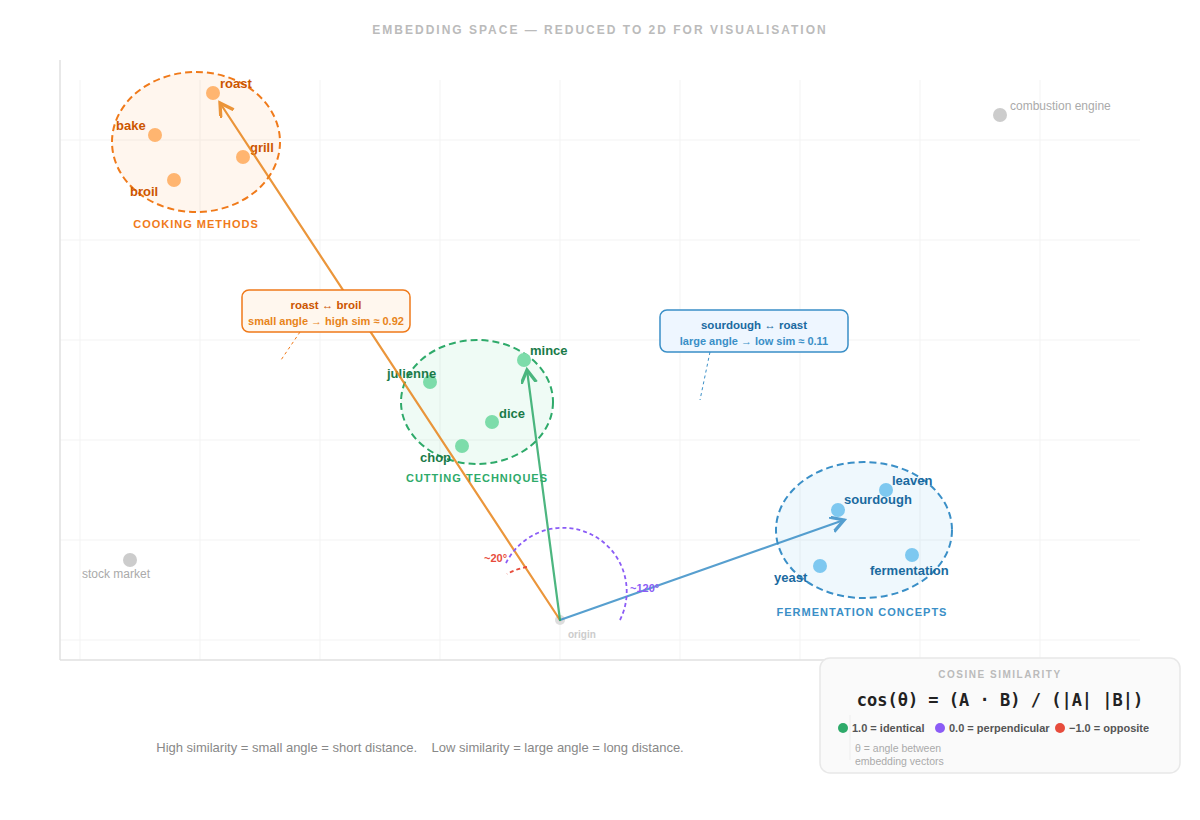
> **[Diagram Caption]** A 2D scatter plot of embedding space showing three recipe-domain word clusters: cooking methods (bake, grill, roast, broil — orange), cutting techniques (chop, dice, julienne, mince — green), and fermentation concepts (yeast, leaven, sourdough, fermentation — blue). Two annotated pairs illustrate cosine similarity: roast ↔ broil sit close together (small angle, sim = 0.92) while sourdough ↔ roast are far apart (large angle, sim = 0.11). Unrelated words like "stock market" and "combustion engine" fall outside all food clusters entirely.


In [ ]:
import numpy as np

def cosine_similarity(vec_a: list, vec_b: list) -> float:
    a, b = np.array(vec_a), np.array(vec_b)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def context_demo(phrases: list[str], model: str = "embeddinggemma") -> None:
    """Show token IDs and pairwise embedding similarities for a list of phrases.

    All phrases should share a common word to illustrate how context shifts meaning.
    Example: ["what is today's date?", "we went on a romantic date", "I ate a date from the tree"]
    """
    # Token IDs — fixed regardless of context
    print("=== Token IDs (fixed — same word, same ID) ===")
    for phrase in phrases:
        show_tokens(phrase, "google/gemma-2-2b")

    # Embedding similarities — shift with context
    print("\n=== Embedding similarity (context-sensitive) ===")
    embeddings = {p: ollama.embed(model=model, input=p)['embeddings'][0] for p in phrases}

    for i, a in enumerate(phrases):
        for b in phrases[i+1:]:
            sim = cosine_similarity(embeddings[a], embeddings[b])
            print(f"  {repr(a):<45} vs {repr(b):<45} → {sim:.3f}")

    print("\nSame token ID each time — but embedding vectors shift with context.")


context_demo([
    "what is today's date?",
    "the date on the document is wrong",
    "we went on a romantic date",
    "I ate a sweet date from the palm tree",
])

#### Interpreting the Numbers

- Closer to **1.0** → the model considers these phrases nearly identical in meaning — they sit close together in its internal representation
- Closer to **0.0** → the model sees them as unrelated — far apart in that same space

> *Note: cosine similarity ranges from −1 to 1. A score near 0 means unrelated; negative scores are possible and indicate vectors pointing in opposite directions.*

In the example above, the two calendar-date phrases ("today's date", "date on the document") end up close to each other (~0.80), while the fruit sense ("sweet date from the palm tree") sits furthest away (~0.58). The romantic date lands in between — it shares the social/event frame with time-keeping, but is nothing like a calendar.

The model never explicitly "knows" these are different meanings of the same word. It learned the distinction entirely from co-occurrence patterns in text. We only see it by measuring.

**Learning:** context shifts meaning — and with it, what the model is likely to predict next. The same word in different sentences doesn't just have a different meaning to *us*; it has a different vector inside the model. That's what we measured above. The natural next question is: does this model's internal map actually reflect the distinctions that *matter for our domain*?

---

### Evaluating Domain Coverage

There is no direct way to inspect what a transformer has learned, but we can study how your domain maps in the embedding space of a model and answer the question: **does your model's embedding space actually capture the words that matter to my use case?**

We can test this by defining word pairs and checking whether the model agrees with your expectations about which words should be close and which should be far. This gives us an idea of whether the internal structure that the model uses to reason is good enough for our use case or not.

**The Process:**
- Pick words from our problem domain
    - Concepts
    - Words that show up often and are the same or contradictory
- Label each pair as `close` (semantically related) or `far` (unrelated)
- Compute cosine similarity
- Check whether the scores match our expectations

A model with poor domain coverage will give surprising or flat scores — it can't distinguish between related and unrelated concepts in our field.

In [22]:
import ollama
import pandas as pd
import numpy as np

def get_embedding(text: str, model: str = "embeddinggemma") -> list:
    return ollama.embed(model=model, input=text)['embeddings'][0]

def cosine_similarity(a, b):
    a = np.array(a)
    b = np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def evaluate_pairs(word_pairs: list, model: str = "embeddinggemma") -> list:
    results = []

    for word_a, word_b, expected in word_pairs:
        emb_a = get_embedding(word_a, model)
        emb_b = get_embedding(word_b, model)

        sim = cosine_similarity(emb_a, emb_b)

        results.append({
            "word_a": word_a,
            "word_b": word_b,
            "expected_association": expected,
            "cosine_similarity": round(sim, 4)
        })

    df = pd.DataFrame(results)
    print(f"\nModel: {model}\n")
    display(df)

    return results

In [ ]:
# Sample pairs from the recipe domain — the course showcase project
# Replace or extend these with words from YOUR problem_statement.md
word_pairs = [
    # close pairs — these should score high
    ("sourdough",  "fermentation",   "close"),
    ("sourdough",  "yeast",          "close"),
    ("recipe",     "ingredients",    "close"),
    ("bake",       "oven",           "close"),
    ("julienne",   "chop",           "close"),
    # far pairs — these should score low
    ("sourdough",  "combustion engine", "far"),
    ("recipe",     "stock market",      "far"),
    ("bake",       "geology",           "far"),
    ("bake",       "roast",             "far")
]

results = evaluate_pairs(word_pairs)


In [ ]:
import numpy as np

def calculate_gap(results: list) -> None:
    close_sims = [r["cosine_similarity"] for r in results if r["expected_association"] == "close"]
    far_sims   = [r["cosine_similarity"] for r in results if r["expected_association"] == "far"]

    close_mean = np.mean(close_sims)
    far_mean   = np.mean(far_sims)
    gap        = close_mean - far_mean

    print(f"Close pairs — mean: {close_mean:.3f}  (n={len(close_sims)})")
    print(f"Far pairs   — mean: {far_mean:.3f}  (n={len(far_sims)})")
    print(f"Gap:          {gap:.3f}", end="  →  ")

    if gap >= 0.2:
        print("model has a useful signal for this domain")
    elif gap >= 0.1:
        print("borderline — consider a dedicated embedding model")
    else:
        print("model is not distinguishing your domain — switch models")

calculate_gap(results)

**Reading the results:**

We're not looking for specific numbers — we're looking for a **gap**. Close pairs should score noticeably higher than far pairs. If both clusters land around 0.6–0.7, the model isn't really distinguishing them, which is a problem.

As a rough guide: a gap of 0.2 or more between our close and far pairs means the model has a useful signal. *(Treat it as a calibration point, not a hard rule — our domain baseline shifts what counts as meaningful.)* A gap of less than 0.1 means it's essentially guessing.

Pairs that surprise we — a `close` pair that scores low, or a `far` pair that scores suspiciously high — are the ones worth paying attention to. Those are where the model's map of meaning doesn't match ours.


**Exercise 2.3: Find our surprises**

Replace the pairs below with words from your own `problem_statement.md`. The goal isn't to confirm the model works — it's to find where it doesn't. Those surprises are our weak spots, and knowing them now means we won't discover them in our results later.

In [ ]:
# TODO: replace these with words from your problem domain
my_domain_pairs = [
    ("word_from_my_domain", "related_word",   "close"),
    ("word_from_my_domain", "unrelated_word",  "far"),
]

my_results = evaluate_pairs(my_domain_pairs)
calculate_gap(my_results)

In [ ]:
import os, pandas as pd

os.makedirs("data", exist_ok=True)
df = pd.DataFrame(my_results)          # my_results from the evaluate_pairs call above
df.to_csv("data/embedding_eval.csv", index=False)
print(f"Saved {len(df)} pairs → data/embedding_eval.csv")


**Note**

> Calling `ollama.embed()` on a generative model like `gemma2:2b` works — but we are using a model that was trained to predict text, not to produce similarity-optimized vectors. The resulting embeddings are a by-product, not the primary objective, which is why dedicated embedding models consistently produce cleaner separations on similarity tasks.


---

### Dedicated Embedding Models

`gemma2:2b` is a *generative* model — embeddings are a by-product of its internal representation,
not its primary job.

Dedicated embedding models are trained specifically to produce high-quality semantic similarity vectors. They are typically smaller and faster than generative models.

`sentence-transformers` is the standard Python library for this and the most common base models are:

| Model | Architecture | Dimensions | Size | Notes |
|---|---|---|---|---|
| `all-MiniLM-L6-v2` | Encoder | 384 | ~90 MB | Fast, good general quality — project default |
| `all-mpnet-base-v2` | Encoder | 768 | ~420 MB | Slower, higher quality |
| `GTE-Qwen2-1.5B-instruct` | Decoder | 1536 | ~3 GB | Fine-tuned from Qwen2-1.5B; strong MTEB scores at this size |
| `SmolLM2-1.7B` (community fine-tunes) | Decoder | varies | ~3.5 GB | Generative-first; community embedding variants available |

#### Using Dedicated Embedding Models

Dedicated embedding models do not plug directly into a generative model — the two communicate via text. A common pattern is retrieval-augmented generation (RAG), where an embedding model retrieves relevant context and that context is passed as part of the prompt to the generative model. We will cover this in detail in a later week. We can now compare how well a dedicated embedding model performs relative to `gemma2:2b`.

In [ ]:
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer("all-MiniLM-L6-v2")

print(f"Model loaded. Embedding dimensions: {st_model.get_embedding_dimension()}")

In [ ]:
def evaluate_pairs_st(word_pairs: list, model: SentenceTransformer, label: str = "all-MiniLM-L6-v2") -> list:
    """Same evaluation as evaluate_pairs(), but using a sentence-transformers model."""
    results = []
    for word_a, word_b, expected in word_pairs:
        emb_a = st_model.encode(word_a).tolist()
        emb_b = st_model.encode(word_b).tolist()
        sim = cosine_similarity(emb_a, emb_b)
        results.append({
            "word_a": word_a, "word_b": word_b,
            "expected_association": expected,
            "model": label,
            "cosine_similarity": round(sim, 4)
        })

    print(f"Model: {label}")
    display(pd.DataFrame(results).drop(columns="model"))
    return results

results_st = evaluate_pairs_st(word_pairs, st_model)


**Exercise 2.4: Compare the two models**

We now have scores from two different approaches — `gemma2:2b` (a generative model used as an embedder) and `all-MiniLM-L6-v2` (trained specifically for similarity). Look at them side by side and notice:

- Which one creates a cleaner gap between our `close` and `far` pairs?
- Are there pairs where they flat-out disagree?
- Does either one surprise you for our own domain words?

`all-MiniLM-L6-v2` is the model our project will use. This comparison is why — a model trained for the job tends to give cleaner separations than one borrowed for it. The MTEB leaderboard in Part 3 formalises exactly this kind of comparison across thousands of tasks.

In [ ]:

# Write one observation from comparing the two models
observation = input("One thing I noticed comparing the two models: ")
print(observation)

#### Not All Embedding Models Are Equal

The [MTEB leaderboard](https://huggingface.co/spaces/mteb/leaderboard) (Muennighoff et al., EACL 2023)
is the standard way to compare embedding models across 8 task types and 58 datasets.

**How to use it for our project:**
1. Filter by task type — **STS** (Semantic Textual Similarity) or **Classification** are most relevant here
2. Check model size — bigger is not always better if we need to run locally
3. Cross-reference with our `calculate_gap` results from Exercise 2.3

**Decoder-based models and transfer learning:**
Models like `GTE-Qwen2-1.5B-instruct` are fine-tuned directly from the Qwen2-1.5B generative model's weights. This means they share the same internal representation space as Qwen2.5 — the same "understanding" of language. When we fine-tune the embedding model on our domain pairs, we are adapting that shared space, and the improvement transfers to how the generative model also "sees" our domain. This is a lightweight form of transfer learning: improve retrieval quality for your specific domain. Note: the embedding model and generative model have separate weights — fine-tuning one has no effect on the other.

---
**Supplementary Exercise: Fine-tune an embedding model on our domain pairs**

*Optional — not required for the project, but useful if our `calculate_gap` is borderline.*

1. Collect our domain pairs from Exercise 2.3 into a Hugging Face `Dataset` with columns
   `sentence1`, `sentence2`, `label` (1.0 for close, 0.0 for far)
2. Load a base model: `SentenceTransformer("all-MiniLM-L6-v2")` or `"Alibaba-NLP/gte-Qwen2-1.5B-instruct"`
3. Fine-tune with `SentenceTransformerTrainer` using `CoSENTLoss`
4. Re-run `calculate_gap` on the fine-tuned model and compare

**References:**
- [Sentence-transformers training overview](https://sbert.net/docs/training/overview.html)
- [GTE-Qwen2-1.5B-instruct model card](https://huggingface.co/Alibaba-NLP/gte-Qwen2-1.5B-instruct)

More domain pairs = more reliable fine-tuning signal. Aim for 50+ pairs before fine-tuning.

---

## Under the Hood

Having covered tokenization, embeddings, and model comparison, this section goes under the hood: how vocabularies are built, how position is encoded, and why these choices matter for our use case.


### Advanced Tokenization: How Vocabularies Get Built

**Why this matters for our domain first:** in the evaluation above, some of our word pairs may have returned flat or surprising scores. One likely cause: the model has never seen our term as a single unit — it was split into small, generic pieces during training. BPE explains why.

#### Byte Pair Encoding (BPE) — What Gemma Uses

BPE is how Gemma's vocabulary was built:

1. Start with individual characters
2. Find the most frequently co-occurring pair across all training text
3. Merge it into a new vocabulary entry
4. Repeat until the vocabulary hits its target size (~256,000 for Gemma)

So `sourdough` might end up as `["sourdough"]` (one token, appeared a lot in training) or `["sour", "dough"]` (two tokens, appeared less). A rare culinary term like `escabeche` will almost certainly fragment into small pieces because it barely appeared in training.


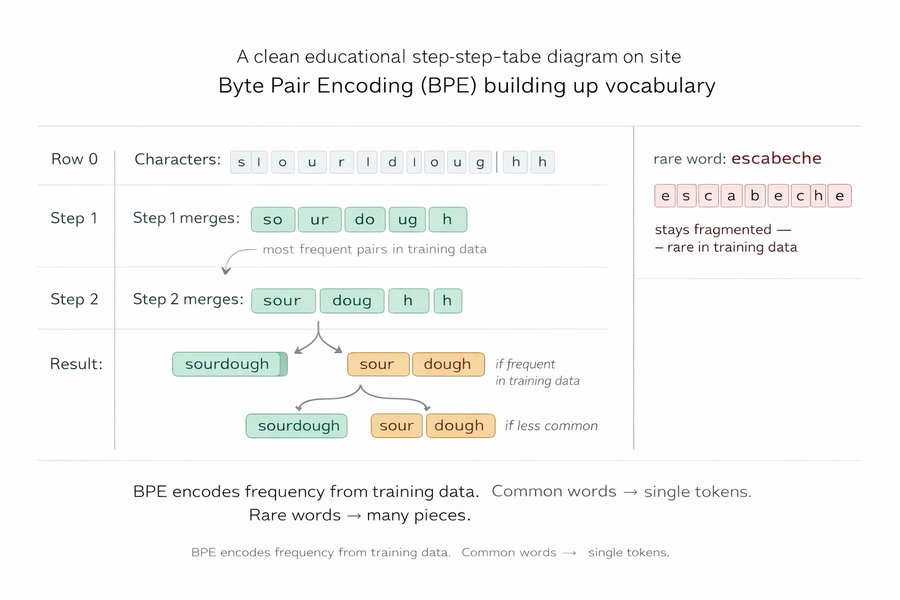
> **[Diagram Caption]** Step-by-step BPE merge diagram titled "Byte Pair Encoding (BPE) building up vocabulary." Row 0: individual characters s·i·o·u·r·d·i·o·u·g·h·h. Step 1 merges: the most frequent adjacent pairs become so, ur, do, ug, h. Step 2 merges again: sour, dough, h, h. Result row branches: if "sourdough" is frequent in training it becomes a single token; if less common it stays as "sour" + "dough" (two tokens). The right column shows the rare culinary word "escabeche" remaining fully fragmented into individual letters because it barely appeared in training data. The footer reads "BPE encodes frequency from training data. Common words → single tokens. Rare words → many pieces."



#### Byte Level Encoding

These models (GPT-2, LLaMA) use **Byte-Level BPE** — same idea but operating on raw bytes instead of characters, so no word is ever fully unknown and is completely language agnostic though the trade-off is slightly longer sequences.

When we're choosing a model for our domain on the MTEB leaderboard, we're partly making this choice too.

### Embedding Word Positions

Positional embedding tells the model *where* in the sequence it appears and this information also gets encoded into transformers because the position of words significantly affects their meaning.

A million *0s* before *1* means something different from a million *0s* after *1*. Without positional information, a transformer would treat them identically.

##### Rotary Position Embeddings
Instead of *adding* a position signal, Rotary Position Embedding *rotates* the token vector by an angle proportional to its position. When attention computes the dot product between two token vectors, the result encodes their *relative distance* — how far apart they are in the sequence — rather than their absolute positions. So the model learns "these two tokens are 5 positions apart" rather than "this token is at position 37". Relative distance is more transferable and more useful for most linguistic relationships.

This technique makes LLMs more precise at understanding positional relationships in language. It also means the model must be trained up to a maximum sequence length — the **context window** — beyond which the rotation angles fall outside the trained range and attention scores become unreliable.

Gemma 2 2B supports up to 8,192 tokens. Beyond that, the rotation angles land outside the trained range and attention scores become unreliable.

---

## Key Takeaways

Tokenization and embeddings are the foundation of how an LLM processes language. A few things worth holding onto as we move forward:

- **Tokens are not words.** Each model has a fixed vocabulary; unusual or domain-specific terms fragment into smaller sub-word pieces. A fragmented term has a weaker, less precise internal representation.
- **Different phrases produce distinct embedding vectors.** Even when phrases share surface-level words, their embedding vectors differ — which is why modern LLMs outperform older word-lookup approaches on nuanced tasks.
- **Not all models embed equally.** Generative models like `gemma2:2b` produce embeddings as a side-effect of text prediction. Dedicated embedding models like `all-MiniLM-L6-v2` are trained specifically for semantic similarity and typically produce cleaner separations.
- **`calculate_gap` is our calibration signal.** A gap of 0.2 or more between close and far pair scores means the model has a useful representation of our domain. Below 0.1, it is essentially treating our terms as interchangeable.


---

**Your assignment:**

1. Create at least 20 domain_pairs similar to (Exercise 2.3) for your problem_statement.md
2. Run the full evaluation and save your embedding_eval.csv
3. If calculate_gap showed a weak signal (< 0.2), use the MTEB leaderboard to find another model
4. Create a reusable evaluation script that reads your domain_pairs, calls ollama.embed(), and writes results to embedding_eval.csv


---

**Supplementary resources — if you want to go deeper:**
- [Jay Alammar's illustrated word2vec — visual, intuitive](https://jalammar.github.io/illustrated-word2vec/)
- [Tiktokenizer — see how any text gets tokenized by different models](https://tiktokenizer.vercel.app/)
- [MTEB Leaderboard](https://huggingface.co/spaces/mteb/leaderboard)
- [HuggingFace Primer on embeddings](https://huggingface.co/spaces/hesamation/primer-llm-embedding)